## Project

The goal of this project is to classify breast cancer samples as **malignant** or **benign** using the **Breast Cancer Wisconsin Diagnostic dataset**.

This is a **supervised binary classification problem** because the dataset contains both input features and known diagnosis labels. Each sample is described by **30 numerical features** extracted from cell nuclei, while the target variable represents the final diagnosis.

The project follows a classical **applied machine learning workflow**, including data loading, exploratory data analysis, preprocessing, model comparison, hyperparameter tuning, and final evaluation.

The main goal is not only to obtain high predictive performance, but also to evaluate the models using appropriate metrics for a medical classification problem, especially because missing malignant cases can be clinically important.

## Import libraries

In [187]:
# Data manipulation and numerical operations
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt

# Dataset
from sklearn.datasets import load_breast_cancer

# Data splitting, cross-validation, and hyperparameter tuning
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV

# Preprocessing and pipelines
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    make_scorer
)

#### Import libraries
In this section, I imported the Python libraries needed for the different steps of the machine learning workflow.

**NumPy** and **Pandas** are used for numerical operations and data manipulation. **Matplotlib** is used for data visualization during exploratory data analysis. **Scikit-learn** is used for dataset loading, train-test splitting, feature scaling, model training, model evaluation, cross-validation, hyperparameter tuning, and Pipeline construction.

Importing the libraries at the beginning makes the notebook more organized and helps clarify which tools are used in each part of the project.


## Load dataset

In [188]:
# Load the Breast Cancer Wisconsin Diagnostic dataset
cancer = load_breast_cancer()

# Convert the data into a pandas DataFrame
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)

# Add the target column
df["target"] = cancer.target

# Show the first 5 rows
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


#### Load dataset

In this section, I loaded the **Breast Cancer Wisconsin Diagnostic dataset** and converted it into a **Pandas DataFrame**.

This conversion makes the dataset easier to inspect, manipulate, and analyze because the feature names become explicit column names. Each row represents one breast mass sample, and each column represents a numerical feature extracted from cell nuclei.

The **target column** contains the true diagnosis label, which will be used as the output variable for the supervised classification task.


## Dataset overview

The **Breast Cancer Wisconsin Diagnostic dataset** contains measurements computed from digitized images of **fine needle aspirate (FNA) biopsies** of breast masses.

Each sample is described by **30 numerical features** that characterize the properties of cell nuclei. These features include measurements such as **radius**, **texture**, **perimeter**, **area**, **smoothness**, **compactness**, **concavity**, and **symmetry**.

The target variable represents the diagnosis of each sample:

* **0 = malignant**
* **1 = benign**

Since the dataset contains input features together with known diagnosis labels, this is a **supervised learning** problem. Because the target variable has only two possible classes, it is specifically a **binary classification** task.


## Understanding target labels

In [189]:
# Check target names
cancer.target_names

array(['malignant', 'benign'], dtype='<U9')

In [190]:
# Count target labels
df["target"].value_counts()

,count
target,
1,357
0,212


In [191]:
# Map numeric labels to class names
df["diagnosis"] = df["target"].map({
    0: "malignant",
    1: "benign"
})

df["diagnosis"].value_counts()

,count
diagnosis,
benign,357
malignant,212


#### Understanding the target labels

Before evaluating the models, I checked how the target labels are encoded in the dataset.

In this dataset, the diagnosis labels are encoded as:

* **0 = malignant**
* **1 = benign**

This step is important because many scikit-learn evaluation metrics, such as **precision** and **recall**, treat label **1** as the positive class by default.

However, in this medical classification task, the **malignant class** is clinically more critical. Therefore, I later computed malignant-specific metrics separately using `pos_label=0`.


## Dataset shape, info and describe

In [192]:
# Dataset shape
df.shape

(569, 32)

In [193]:
# General information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [194]:
# Summary statistics
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


#### Dataset shape, information and descriptive statistics

Before building any machine learning model, I inspected the basic structure of the dataset using `shape`, `info()`, and `describe()`.

The dataset contains **569 samples** and **30 original numerical features**. After adding the `target` column and the human-readable `diagnosis` column, the DataFrame contains **32 columns** in total.

The `info()` output confirms that the features are numerical and helps check the data types and possible missing values. The `describe()` output provides descriptive statistics such as mean, standard deviation, minimum, and maximum values.

These statistics show that the features have **different numerical ranges**. This is important because some models, such as **Logistic Regression**, **KNN**, and **SVM**, are sensitive to feature scale. Therefore, feature scaling will be applied before training these models.


## Exploratory Data Analysis

In this section, I performed **Exploratory Data Analysis (EDA)** before training any machine learning model.

The goal of EDA is to better understand the dataset, check data quality, and identify important patterns that may affect the modelling process. In particular, I checked for **missing values**, inspected the **class distribution**, analyzed **feature ranges**, and visualized selected feature patterns.

This step is important because machine learning models depend strongly on the quality and structure of the input data. Understanding the dataset before training helps avoid mistakes such as using incomplete data, ignoring class imbalance, or applying models without proper preprocessing.


## Missing values

In [195]:
# Check missing values in each column
df.isnull().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


In [196]:
# Total number of missing values
df.isnull().sum().sum()

np.int64(0)

#### Missing values

I checked the dataset for **missing values** before training the models.

No missing values were found in the dataset. Therefore, no imputation strategy was needed, and all samples could be kept for the analysis.

This is important because many machine learning algorithms in scikit-learn cannot handle missing values directly. If missing values had been present, I would have needed to apply a preprocessing strategy such as removing incomplete samples or replacing missing values using mean, median, or another imputation method.


## Class balance

In [197]:
# Count the number of samples in each diagnosis class
class_counts = df["diagnosis"].value_counts()
class_counts

,count
diagnosis,
benign,357
malignant,212


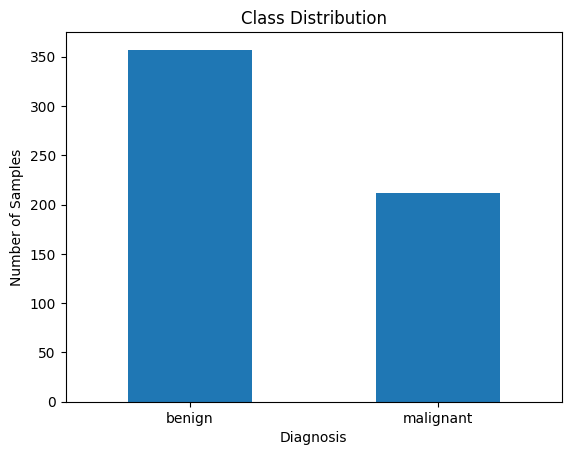

In [198]:
# Plot class distribution
class_counts.plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.show()

#### Class balance

I checked the distribution of the target classes to see whether the dataset is balanced.

The dataset is **moderately imbalanced**, with more **benign** samples than **malignant** samples:

* **Benign samples:** 357
* **Malignant samples:** 212

This imbalance is important because **accuracy alone may be misleading**. A model could achieve a high accuracy mainly by predicting the majority class correctly, while still missing some malignant cases.

Since this is a **medical diagnosis task**, the **recall for the malignant class** is especially important. A **false negative** means that a malignant sample is incorrectly predicted as benign, which may correspond to a missed cancer case.


## Separate features and target

In [199]:
# Separate features and target
X = df.drop(columns=["target", "diagnosis"])
y = df["target"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (569, 30)
Target vector shape: (569,)


#### Separate features and target

In this step, I separated the input features from the target variable.

The input matrix `X` contains only the **30 numerical features** used for prediction. The target vector `y` contains the **true diagnosis labels**.

Both the `target` and `diagnosis` columns are excluded from `X` to avoid **data leakage**. The `target` column contains the true label, and the `diagnosis` column is only a human-readable version of the same label. If either of them were included in the input features, the model would indirectly see the correct answer during training.


## Feature ranges and scaling motivation

In [200]:
# Show min and max values for each feature
feature_ranges = pd.DataFrame({
    "min": X.min(),
    "max": X.max()
})

feature_ranges.head(10)

,min,max
mean radius,6.98100,28.11000
mean texture,9.71000,39.28000
mean perimeter,43.79000,188.50000
mean area,143.50000,2501.00000
mean smoothness,0.05263,0.16340
mean compactness,0.01938,0.34540
mean concavity,0.00000,0.42680
mean concave points,0.00000,0.20120
mean symmetry,0.10600,0.30400
mean fractal dimension,0.04996,0.09744


#### Feature ranges and scaling motivation

The features have **different numerical ranges**. For example, area-related features have much larger values than smoothness or symmetry features. Therefore, **feature scaling** is necessary before training scale-sensitive models such as **Logistic Regression**, **KNN**, and **SVM**.

In this project, scaling will be handled inside **Pipeline** objects during model comparison and hyperparameter tuning. This means the scaler is fitted only on the training data inside each cross-validation fold, which helps avoid **data leakage**.

For the final model, the same Pipeline will also be used on the test set, so preprocessing and prediction are applied consistently.


## Feature distribution analysis

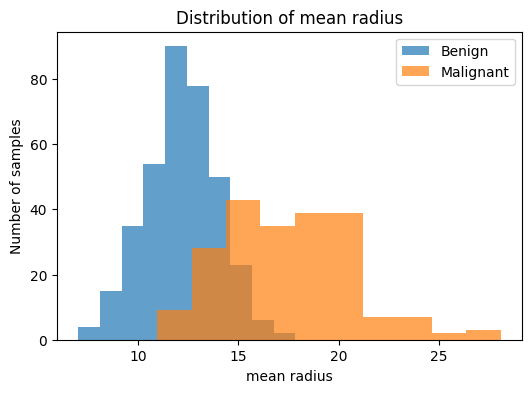

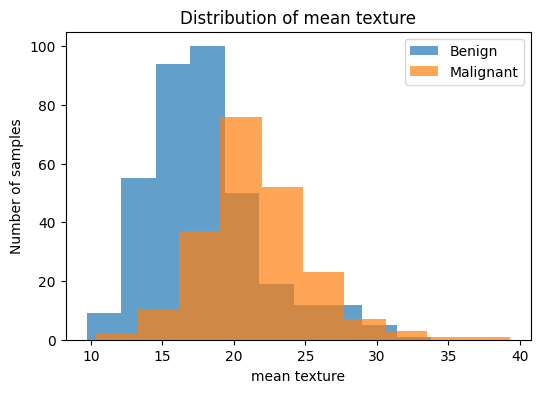

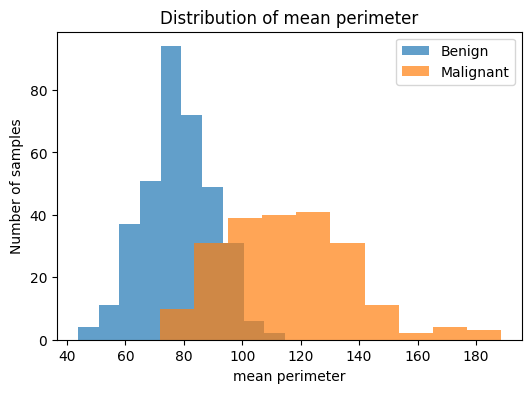

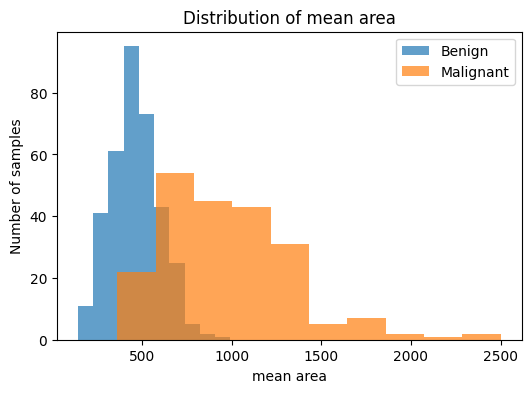

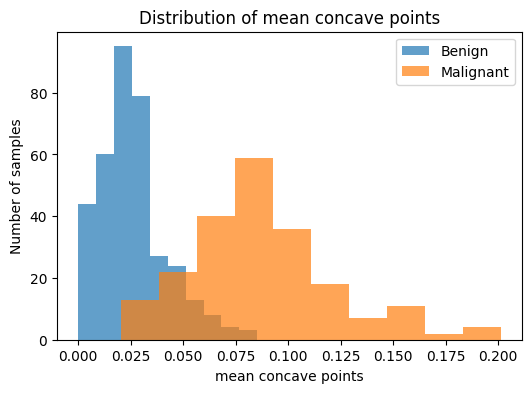

In [201]:
# Select a few important and interpretable features
selected_features = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean concave points"
]

for feature in selected_features:
    plt.figure(figsize=(6, 4))

    plt.hist(df[df["diagnosis"] == "benign"][feature], alpha=0.7, label="Benign")
    plt.hist(df[df["diagnosis"] == "malignant"][feature], alpha=0.7, label="Malignant")

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Number of samples")
    plt.legend()
    plt.show()

#### Feature distribution analysis

To better understand the relationship between the input features and the diagnosis, I visualized the distribution of selected features for **benign** and **malignant** samples.

I selected features such as **mean radius**, **mean texture**, **mean perimeter**, **mean area**, and **mean concave points** because they are biologically interpretable and describe important characteristics of cell nuclei.

This analysis helps identify whether some features show different patterns between the two diagnosis classes. If the distributions of benign and malignant samples are clearly separated for a feature, that feature may contain useful information for classification.


## Correlation analysis

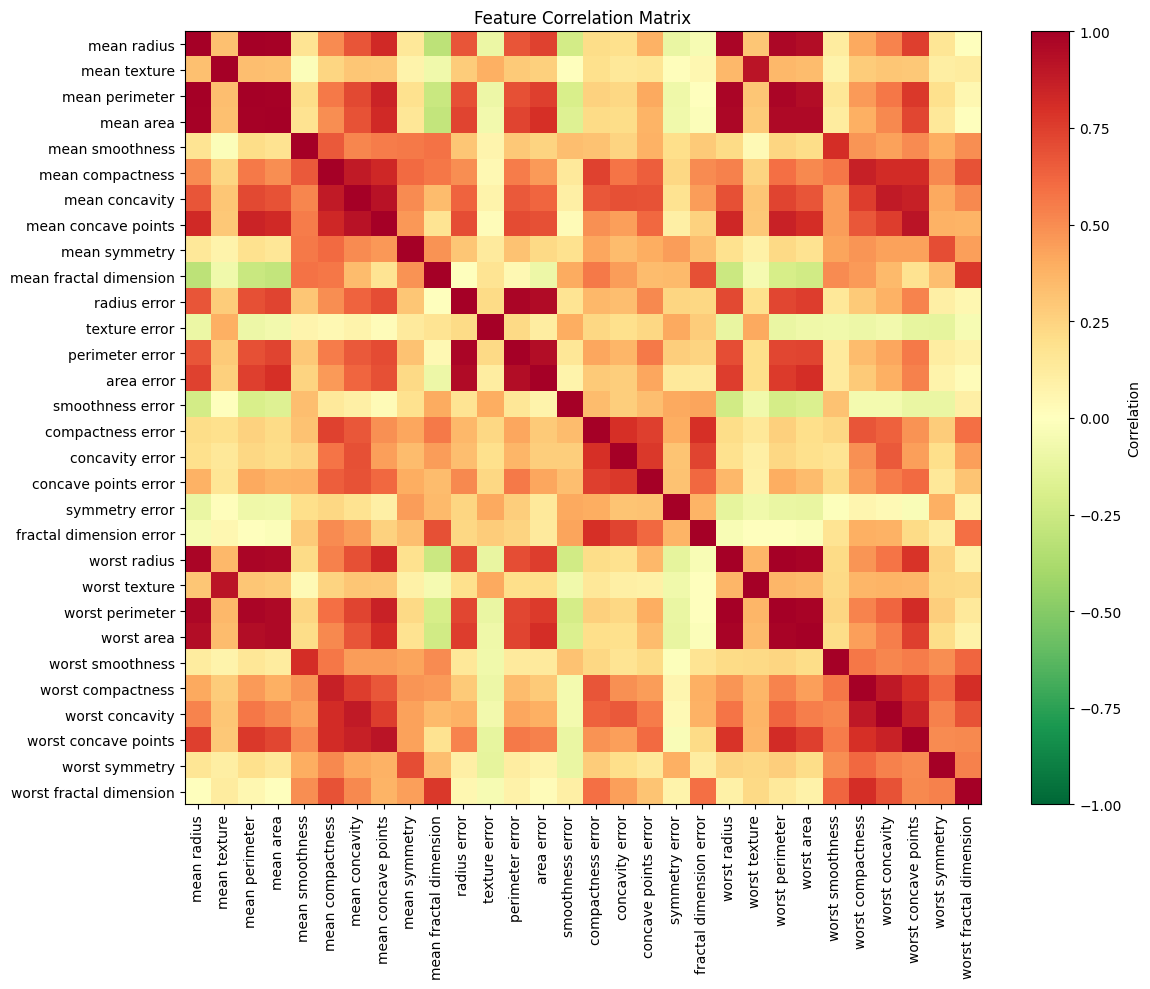

In [202]:
# Compute correlation matrix
corr_matrix = X.corr()

# Plot correlation matrix with green-to-red color scale
plt.figure(figsize=(12, 10))

plt.imshow(
    corr_matrix,
    aspect="auto",
    cmap="RdYlGn_r",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [203]:
# Find highly correlated feature pairs
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > 0.90:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_value
            ))

high_corr_df = pd.DataFrame(
    high_corr_pairs,
    columns=["Feature 1", "Feature 2", "Correlation"]
)

high_corr_df.sort_values(by="Correlation", ascending=False).head(15)

,Feature 1,Feature 2,Correlation
0,mean perimeter,mean radius,0.997855
14,worst perimeter,worst radius,0.993708
1,mean area,mean radius,0.987357
2,mean area,mean perimeter,0.986507
18,worst area,worst radius,0.984015
19,worst area,worst perimeter,0.977578
4,perimeter error,radius error,0.972794
12,worst perimeter,mean perimeter,0.970387
7,worst radius,mean radius,0.969539
8,worst radius,mean perimeter,0.969476


#### Correlation analysis

The dataset contains several related measurements for similar biological properties, such as **mean**, **standard error**, and **worst** values of radius, perimeter, area, smoothness, and other cell nucleus characteristics.

Because of this structure, some features may be **highly correlated**. For example, features related to cell size, such as **radius**, **perimeter**, and **area**, are expected to carry similar information.

I performed correlation analysis to identify relationships between features and to check whether some variables provide overlapping information. This is important because highly correlated features can make the model more complex and may affect interpretation.

Several features show **strong correlations** with each other. However, in this project, I initially kept all features because removing features too early could also remove useful information. Instead, I relied on **model comparison**, **cross-validation**, and **regularization** to control overfitting and evaluate whether the models generalize well to unseen data.


## Train-test split

In [204]:
# Split the dataset into training and test sets
# stratify=y keeps the same benign/malignant proportion in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

Training set shape: (455, 30)
Test set shape: (114, 30)

Training class distribution:
target
1    285
0    170
Name: count, dtype: int64

Test class distribution:
target
1    72
0    42
Name: count, dtype: int64


#### Train-test split

Before model training, I divided the dataset into **training** and **test** sets.

The **training set** is used for model training, model comparison, cross-validation, and hyperparameter tuning. The **test set** is kept unseen until the final evaluation. This is important because using the test set during model selection would give an overly optimistic estimate of model performance.

I used a **stratified split** to preserve the proportion of **benign** and **malignant** samples in both the training and test sets. This is useful because the dataset is moderately imbalanced.

This step helps estimate how well the final selected model can **generalize** to new, unseen data.


## Non-ML baseline

Before training machine learning models, I implemented a simple rule-based baseline using one interpretable feature: **mean concave points**.

This feature was selected because the exploratory data analysis showed visible separation between benign and malignant samples. The rule predicts a sample as malignant when its mean concave points value is above a threshold, and benign otherwise.

The threshold was selected using only the **training set**, which avoids using information from the test set during baseline design. The purpose of this baseline is not to obtain the best possible performance, but to provide a simple and interpretable reference before training multivariate machine learning models.

In [205]:
feature = "mean concave points"

thresholds = np.linspace(
    X_train[feature].min(),
    X_train[feature].max(),
    100
)

results = []

for threshold in thresholds:
    y_pred_train_rule = np.where(X_train[feature] > threshold, 0, 1)

    results.append({
        "threshold": threshold,
        "malignant_recall": recall_score(y_train, y_pred_train_rule, pos_label=0),
        "malignant_f1": f1_score(y_train, y_pred_train_rule, pos_label=0),
        "balanced_accuracy": balanced_accuracy_score(y_train, y_pred_train_rule)
    })

rule_results = pd.DataFrame(results)

best_rule = rule_results.sort_values(
    by="malignant_f1",
    ascending=False
).iloc[0]

best_threshold = best_rule["threshold"]
best_threshold

np.float64(0.04877575757575757)

In [206]:
y_pred_rule = np.where(X_test[feature] > best_threshold, 0, 1)

rule_baseline_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_rule),
    "Balanced accuracy": balanced_accuracy_score(y_test, y_pred_rule),
    "Malignant precision": precision_score(y_test, y_pred_rule, pos_label=0),
    "Malignant recall": recall_score(y_test, y_pred_rule, pos_label=0),
    "Malignant F1-score": f1_score(y_test, y_pred_rule, pos_label=0),
    "MCC": matthews_corrcoef(y_test, y_pred_rule)
}

rule_baseline_metrics

{'Accuracy': 0.9035087719298246,
 'Balanced accuracy': np.float64(0.9136904761904762),
 'Malignant precision': 0.8163265306122449,
 'Malignant recall': 0.9523809523809523,
 'Malignant F1-score': 0.8791208791208791,
 'MCC': np.float64(0.8061979576344277)}

In [207]:
confusion_matrix(y_test, y_pred_rule)

array([[40,  2],
       [ 9, 63]])

### Interpretation of the one-feature baseline

The one-feature rule-based baseline used only **mean concave points**, so it was simple and interpretable. It achieved good malignant recall, but it was limited because it ignored the remaining 29 features and could not model interactions between variables.

This baseline is useful as a transparent reference point before training machine learning models. The machine learning models are expected to improve over this baseline by combining multiple features and learning more flexible decision boundaries.

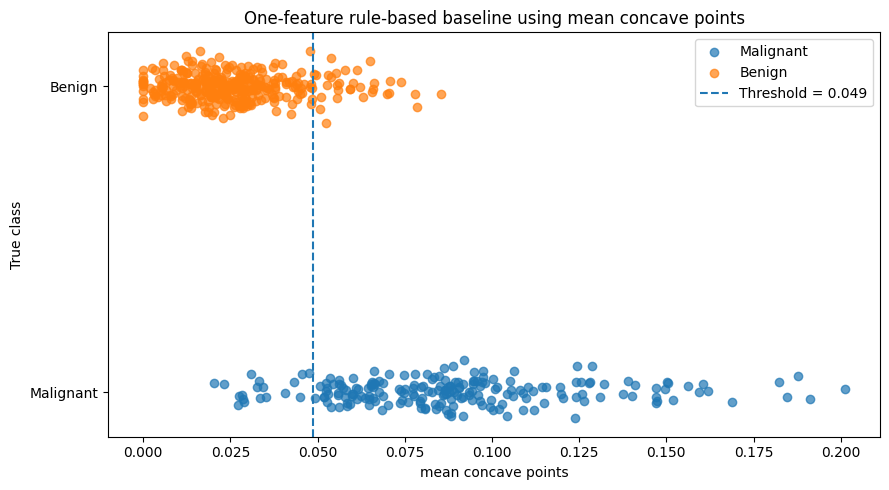

In [208]:
# Visualize the one-feature rule-based baseline
feature = "mean concave points"
threshold = best_threshold  # threshold selected on the training set

# Add vertical jitter to improve visualization
rng = np.random.default_rng(42)
y_jitter = y.map({0: 0, 1: 1}) + rng.normal(0, 0.04, size=len(y))

plt.figure(figsize=(9, 5))

plt.scatter(
    X.loc[y == 0, feature],
    y_jitter[y == 0],
    alpha=0.7,
    label="Malignant",
)

plt.scatter(
    X.loc[y == 1, feature],
    y_jitter[y == 1],
    alpha=0.7,
    label="Benign",
)

plt.axvline(threshold, linestyle="--", label=f"Threshold = {threshold:.3f}")

plt.yticks([0, 1], ["Malignant", "Benign"])
plt.xlabel(feature)
plt.ylabel("True class")
plt.title(f"One-feature rule-based baseline using {feature}")
plt.legend()
plt.tight_layout()
plt.show()

The rule-based baseline used only one feature, so it was simple and interpretable. However, it was limited because it ignored the remaining 29 features and could not model interactions between variables.

The machine learning models are expected to improve over this baseline by combining multiple features and learning more flexible decision boundaries.

As an additional exploratory baseline, I tested a simple rule using two interpretable features: **mean concave points** and **mean area**.

This baseline predicts a sample as malignant if either of the two feature values is above its selected threshold. The thresholds are selected using only the training set, so the test set remains unseen during baseline design.

This rule-based baseline is not used for final model selection. It is included only as an interpretable reference to compare simple manually defined rules with machine learning models that use all 30 features.

## Optional: Two-feature rule-based baseline

In [209]:
feature_1 = "mean concave points"
feature_2 = "mean area"

thresholds_1 = np.linspace(X_train[feature_1].min(), X_train[feature_1].max(), 100)
thresholds_2 = np.linspace(X_train[feature_2].min(), X_train[feature_2].max(), 100)

results = []

for t1 in thresholds_1:
    for t2 in thresholds_2:
        # Rule: predict malignant if either feature is above its threshold
        y_pred_train_rule = np.where(
            (X_train[feature_1] > t1) | (X_train[feature_2] > t2),
            0,  # malignant
            1   # benign
        )

        results.append({
            "threshold_feature_1": t1,
            "threshold_feature_2": t2,
            "malignant_recall": recall_score(y_train, y_pred_train_rule, pos_label=0),
            "malignant_precision": precision_score(y_train, y_pred_train_rule, pos_label=0, zero_division=0),
            "malignant_f1": f1_score(y_train, y_pred_train_rule, pos_label=0),
            "balanced_accuracy": balanced_accuracy_score(y_train, y_pred_train_rule),
            "mcc": matthews_corrcoef(y_train, y_pred_train_rule)
        })

rule_results = pd.DataFrame(results)

best_rule = rule_results.sort_values(
    by="malignant_f1",
    ascending=False
).iloc[0]

best_t1 = best_rule["threshold_feature_1"]
best_t2 = best_rule["threshold_feature_2"]

best_rule

,2423
threshold_feature_1,0.048776
threshold_feature_2,690.737374
malignant_recall,0.958824
malignant_precision,0.848958
malignant_f1,0.900552
balanced_accuracy,0.928535
mcc,0.839526


In [210]:
y_pred_rule = np.where(
    (X_test[feature_1] > best_t1) | (X_test[feature_2] > best_t2),
    0,  # malignant
    1   # benign
)

two_feature_baseline_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_rule),
    "Balanced accuracy": balanced_accuracy_score(y_test, y_pred_rule),
    "Malignant precision": precision_score(y_test, y_pred_rule, pos_label=0, zero_division=0),
    "Malignant recall": recall_score(y_test, y_pred_rule, pos_label=0),
    "Malignant F1-score": f1_score(y_test, y_pred_rule, pos_label=0),
    "MCC": matthews_corrcoef(y_test, y_pred_rule)
}

two_feature_baseline_metrics

{'Accuracy': 0.9035087719298246,
 'Balanced accuracy': np.float64(0.9236111111111112),
 'Malignant precision': 0.7924528301886793,
 'Malignant recall': 1.0,
 'Malignant F1-score': 0.8842105263157894,
 'MCC': np.float64(0.8193800386870199)}

In [211]:
confusion_matrix(y_test, y_pred_rule)

array([[42,  0],
       [11, 61]])

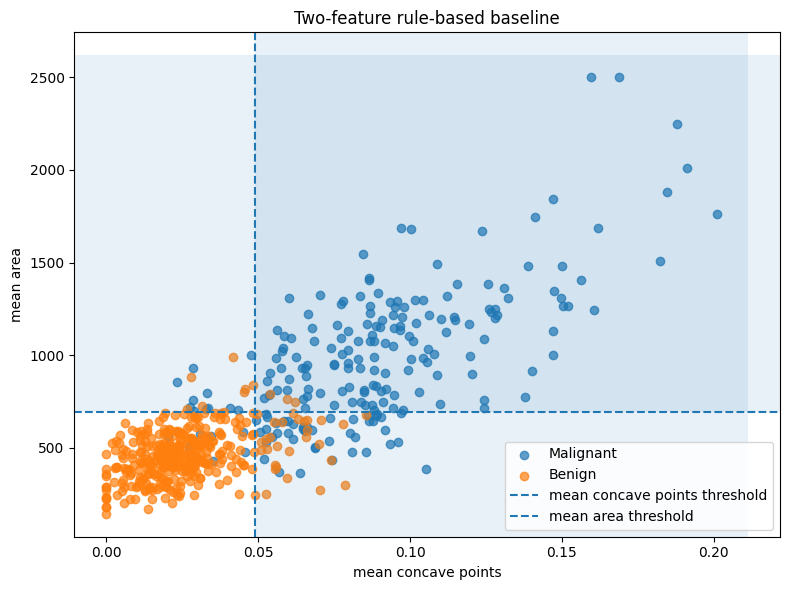

In [212]:
feature_1 = "mean concave points"
feature_2 = "mean area"

t1 = best_t1
t2 = best_t2

plt.figure(figsize=(8, 6))

plt.scatter(
    X.loc[y == 0, feature_1],
    X.loc[y == 0, feature_2],
    alpha=0.7,
    label="Malignant",
)

plt.scatter(
    X.loc[y == 1, feature_1],
    X.loc[y == 1, feature_2],
    alpha=0.7,
    label="Benign",
)

plt.axvline(t1, linestyle="--", label=f"{feature_1} threshold")
plt.axhline(t2, linestyle="--", label=f"{feature_2} threshold")

x_min, x_max = plt.xlim()
y_min, y_max = plt.ylim()

# Region where feature_1 is above the threshold
plt.axvspan(t1, x_max, alpha=0.1)

# Region where feature_2 is above the threshold
plt.axhspan(t2, y_max, alpha=0.1)

plt.xlabel(feature_1)
plt.ylabel(feature_2)
plt.title("Two-feature rule-based baseline")
plt.legend()
plt.tight_layout()
plt.show()

The two-feature rule-based baseline performed better than a trivial majority-class baseline because it used informative features from the dataset. However, it remained limited because it used only two variables and a fixed threshold rule. The machine learning models improved upon this baseline by combining all numerical features and learning more flexible decision boundaries.

## Model comparison with cross-validation

In [213]:
# Define stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define models inside pipelines
model_pipelines = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier())
    ]),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(probability=True, random_state=42))
    ]),

    "Decision Tree": Pipeline([
        ("model", DecisionTreeClassifier(random_state=42))
    ]),

    "Random Forest": Pipeline([
        ("model", RandomForestClassifier(random_state=42))
    ])
}

# Define malignant recall scorer
malignant_recall_scorer = make_scorer(recall_score, pos_label=0)

# Compare models using cross-validation on training data only
cv_comparison_results = []

for model_name, pipeline in model_pipelines.items():
    f1_scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="f1_macro"
    )

    malignant_recall_scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=malignant_recall_scorer
    )

    cv_comparison_results.append({
        "Model": model_name,
        "Mean CV F1-macro": f1_scores.mean(),
        "Std CV F1-macro": f1_scores.std(),
        "Mean CV Malignant Recall": malignant_recall_scores.mean(),
        "Std CV Malignant Recall": malignant_recall_scores.std()
    })

cv_comparison_df = pd.DataFrame(cv_comparison_results)

cv_comparison_df_rounded = cv_comparison_df.copy()
numeric_columns = cv_comparison_df_rounded.select_dtypes(include=["float64"]).columns
cv_comparison_df_rounded[numeric_columns] = cv_comparison_df_rounded[numeric_columns].round(4)

cv_comparison_df_rounded.sort_values(
    by=["Mean CV Malignant Recall", "Mean CV F1-macro"],
    ascending=False
)

,Model,Mean CV F1-macro,Std CV F1-macro,Mean CV Malignant Recall,Std CV Malignant Recall
0,Logistic Regression,0.9764,0.0106,0.9647,0.0288
4,Random Forest,0.9603,0.0188,0.9588,0.0300
2,SVM,0.9669,0.0160,0.9529,0.0399
1,KNN,0.9598,0.0118,0.9294,0.0235
3,Decision Tree,0.9119,0.0190,0.9235,0.0353


#### Model comparison with cross-validation

In this section, I compared several classical machine learning models using **5-fold stratified cross-validation** on the training data only.

The goal of model comparison is to evaluate different algorithms without using the test set. The test set is kept unseen until the final evaluation, so it can provide a realistic estimate of generalization performance.

I used **Pipeline** objects for models that require feature scaling, such as **Logistic Regression**, **KNN**, and **SVM**. This ensures that scaling is fitted separately inside each cross-validation fold and helps avoid data leakage.

The models were compared using **F1-macro** and **malignant recall**. F1-macro gives equal importance to both classes, while malignant recall is especially important in this medical diagnosis task because false negatives may correspond to missed cancer cases.


## Hyperparameter tuning

After comparing the models using cross-validation, I applied hyperparameter tuning to the two strongest candidate models: **Logistic Regression** and **SVM**.

I used **GridSearchCV** together with **Pipeline**. The Pipeline ensures that feature scaling is performed inside each cross-validation fold, which helps avoid data leakage during model selection.

The test set was not used during hyperparameter tuning. It was kept unseen and used only for the final evaluation.


## 1. Logistic Regression tuning

In [214]:
# Hyperparameter tuning for Logistic Regression using Pipeline
logreg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

logreg_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs"]
}

logreg_grid = GridSearchCV(
    estimator=logreg_pipeline,
    param_grid=logreg_param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

logreg_grid.fit(X_train, y_train)

print("Best Logistic Regression parameters:")
print(logreg_grid.best_params_)

print("Best Logistic Regression CV score:")
print(round(logreg_grid.best_score_, 4))

Best Logistic Regression parameters:
{'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best Logistic Regression CV score:
0.9811


## 2. SVM tuning

In [215]:
# Hyperparameter tuning for SVM using Pipeline
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(probability=True, random_state=42))
])

svm_param_grid = {
    "model__C": [0.1, 1, 10, 100],
    "model__kernel": ["linear", "rbf"],
    "model__gamma": ["scale", "auto"]
}

svm_grid = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

svm_grid.fit(X_train, y_train)

print("Best SVM parameters:")
print(svm_grid.best_params_)

print("Best SVM CV score:")
print(round(svm_grid.best_score_, 4))

Best SVM parameters:
{'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'linear'}
Best SVM CV score:
0.9739


## Summary of tuning results

In [216]:
print("Cross-validation model comparison:")

display(
    cv_comparison_df_rounded.sort_values(
        by=["Mean CV Malignant Recall", "Mean CV F1-macro"],
        ascending=False
    )
)

print("\nBest Logistic Regression parameters:")
print(logreg_grid.best_params_)
print("Best Logistic Regression CV score:", round(logreg_grid.best_score_, 4))

print("\nBest SVM parameters:")
print(svm_grid.best_params_)
print("Best SVM CV score:", round(svm_grid.best_score_, 4))

Cross-validation model comparison:


,Model,Mean CV F1-macro,Std CV F1-macro,Mean CV Malignant Recall,Std CV Malignant Recall
0,Logistic Regression,0.9764,0.0106,0.9647,0.0288
4,Random Forest,0.9603,0.0188,0.9588,0.0300
2,SVM,0.9669,0.0160,0.9529,0.0399
1,KNN,0.9598,0.0118,0.9294,0.0235
3,Decision Tree,0.9119,0.0190,0.9235,0.0353



Best Logistic Regression parameters:
{'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best Logistic Regression CV score: 0.9811

Best SVM parameters:
{'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'linear'}
Best SVM CV score: 0.9739


## Final model selection

After model comparison and hyperparameter tuning, **Logistic Regression** was selected as the final model.

This decision was based on its strong cross-validation performance, high malignant recall, and good interpretability. Interpretability is important in medical machine learning because models should not only perform well, but should also be understandable and explainable.

Although SVM also achieved strong results, Logistic Regression was preferred because it provided comparable performance with a simpler and more interpretable model structure.

The final model was selected before evaluating the test set, so the test set remained independent and was used only once for the final performance estimate.


## Final model evaluation on test set

In [217]:
# Select the best Logistic Regression pipeline from GridSearchCV
final_model = logreg_grid.best_estimator_

# Predict on the test set
y_pred_final = final_model.predict(X_test)

# Probability of malignant class = class 0
y_proba_malignant = final_model.predict_proba(X_test)[:, 0]

# Convert labels so malignant becomes 1 and benign becomes 0
y_test_malignant = (y_test == 0).astype(int)

In [218]:
# Final evaluation metrics
final_accuracy = accuracy_score(y_test, y_pred_final)
final_balanced_accuracy = balanced_accuracy_score(y_test, y_pred_final)

final_precision_benign = precision_score(y_test, y_pred_final, pos_label=1)
final_recall_benign = recall_score(y_test, y_pred_final, pos_label=1)
final_f1_benign = f1_score(y_test, y_pred_final, pos_label=1)

final_precision_malignant = precision_score(y_test, y_pred_final, pos_label=0)
final_recall_malignant = recall_score(y_test, y_pred_final, pos_label=0)
final_f1_malignant = f1_score(y_test, y_pred_final, pos_label=0)

final_mcc = matthews_corrcoef(y_test, y_pred_final)
# ROC-AUC for malignant as the positive class
final_roc_auc = roc_auc_score(y_test_malignant, y_proba_malignant)

print("Final Logistic Regression performance on test set:")
print("Accuracy:", round(final_accuracy, 4))
print("Balanced accuracy:", round(final_balanced_accuracy, 4))
print("Benign precision:", round(final_precision_benign, 4))
print("Benign recall:", round(final_recall_benign, 4))
print("Benign F1-score:", round(final_f1_benign, 4))
print("Malignant precision:", round(final_precision_malignant, 4))
print("Malignant recall:", round(final_recall_malignant, 4))
print("Malignant F1-score:", round(final_f1_malignant, 4))
print("MCC:", round(final_mcc, 4))
print("ROC-AUC:", round(final_roc_auc, 4))

Final Logistic Regression performance on test set:
Accuracy: 0.9737
Balanced accuracy: 0.9692
Benign precision: 0.9726
Benign recall: 0.9861
Benign F1-score: 0.9793
Malignant precision: 0.9756
Malignant recall: 0.9524
Malignant F1-score: 0.9639
MCC: 0.9433
ROC-AUC: 0.9957


In [219]:
# Store final evaluation metrics in a table
final_results_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced accuracy",
        "Benign precision",
        "Benign recall",
        "Benign F1-score",
        "Malignant precision",
        "Malignant recall",
        "Malignant F1-score",
        "MCC",
        "ROC-AUC"
    ],
    "Value": [
        final_accuracy,
        final_balanced_accuracy,
        final_precision_benign,
        final_recall_benign,
        final_f1_benign,
        final_precision_malignant,
        final_recall_malignant,
        final_f1_malignant,
        final_mcc,
        final_roc_auc
    ]
})

final_results_df["Value"] = final_results_df["Value"].round(4)
final_results_df

,Metric,Value
0,Accuracy,0.9737
1,Balanced accuracy,0.9692
2,Benign precision,0.9726
3,Benign recall,0.9861
4,Benign F1-score,0.9793
5,Malignant precision,0.9756
6,Malignant recall,0.9524
7,Malignant F1-score,0.9639
8,MCC,0.9433
9,ROC-AUC,0.9957


In [220]:
# Final confusion matrix
final_cm = confusion_matrix(y_test, y_pred_final)

print("Final Confusion Matrix:")
print(final_cm)

Final Confusion Matrix:
[[40  2]
 [ 1 71]]


The final confusion matrix shows that the model correctly classified **40 malignant** samples and **71 benign** samples. However, the final model produced **2 false negatives** for the malignant class, meaning that **2 malignant samples were incorrectly predicted as benign**.

This confirms why **malignant recall** is a key metric in this project. In a medical diagnosis task, false negatives are clinically important because they may correspond to missed cancer cases.

In [221]:
# Detailed classification report
print(classification_report(
    y_test,
    y_pred_final,
    target_names=cancer.target_names
))

              precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        42
      benign       0.97      0.99      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



## Final model evaluation on the test set

After model comparison, cross-validation, and hyperparameter tuning, Logistic Regression was selected as the final model.

The final model was evaluated on the **test set**, which was kept unseen during training, model comparison, cross-validation, and hyperparameter tuning. This is important because the test set provides the final estimate of how well the model generalizes to new data.

The final Logistic Regression model was evaluated using **accuracy**, **balanced accuracy**, **precision**, **recall**, **F1-score**, **MCC**, **ROC-AUC**, and the **confusion matrix**.

Since this is a medical diagnosis task, **malignant recall** and the **confusion matrix** are especially important. Malignant recall measures how many real malignant cases were correctly detected, while the confusion matrix shows the exact number and type of classification errors.


## ROC curve

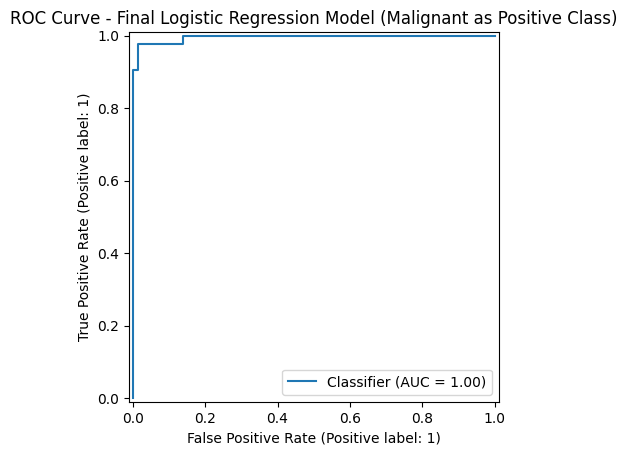

In [222]:
# Plot ROC curve for malignant class as the positive class
RocCurveDisplay.from_predictions(
    y_test_malignant,
    y_proba_malignant
)

plt.title("ROC Curve - Final Logistic Regression Model (Malignant as Positive Class)")
plt.show()

#### ROC curve

The ROC curve was plotted by treating the **malignant class** as the positive class. This is more appropriate for this medical diagnosis task because malignant cases are clinically more critical. The curve shows the ability of the final model to distinguish malignant samples from benign samples across different classification thresholds.


## Conclusion

In this project, several classical machine learning models were applied to the **Breast Cancer Wisconsin Diagnostic dataset** to classify samples as **malignant** or **benign**.

The dataset contained **569 samples** and **30 numerical features**. No missing values were found. The dataset was moderately imbalanced, with more benign than malignant samples, so **accuracy alone** was not considered sufficient for evaluation.

After exploratory data analysis, preprocessing, model comparison with cross-validation, Pipeline-based hyperparameter tuning, and final test evaluation, **Logistic Regression** was selected as the final model. It achieved strong performance on both cross-validation and the test set, with high F1-score, high ROC-AUC, and high recall for the malignant class.

For this medical classification task, **malignant recall** is particularly important because false negatives may correspond to missed cancer cases. The final confusion matrix was used to inspect the exact number and type of classification errors.

Although the final model achieved very strong performance, it should not be used alone in real clinical applications. Instead, it could be considered as a **decision-support tool** together with expert medical evaluation.

A limitation of this project is that the dataset is relatively small and already clean. Future work could include testing the model on external clinical datasets, exploring feature selection methods, using threshold optimization, and analyzing model interpretability in more detail.


# *** LLM usage declaration

LLMs were used for code debugging, language polishing, refactoring, and improving the clarity of explanations. All methodological choices, experiments, outputs, and interpretations were reviewed, checked, and validated by me.